In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

In [11]:
df = pd.read_csv("Diabetes.csv")

df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [12]:
df.shape

(2768, 10)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB


In [14]:
df.describe()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,1384.500000,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,799.197097,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,692.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,1384.500000,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,2076.250000,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,2768.000000,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


In [15]:
df.isnull().sum()

Id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
(df == 0).sum()

Id                             0
Pregnancies                  412
Glucose                       18
BloodPressure                125
SkinThickness                800
Insulin                     1330
BMI                           39
DiabetesPedigreeFunction       0
Age                            0
Outcome                     1816
dtype: int64

In [17]:
df['Outcome'].value_counts()

Outcome
0    1816
1     952
Name: count, dtype: int64

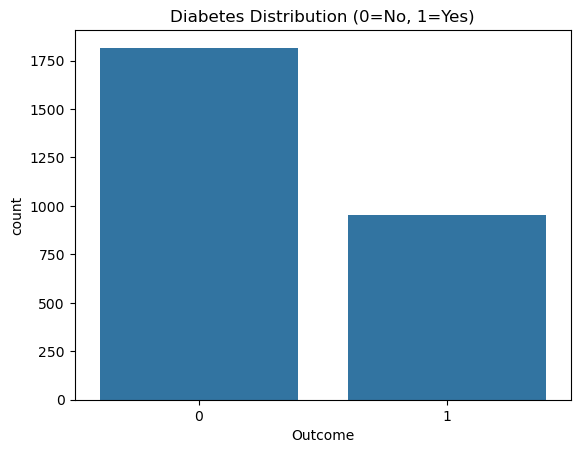

In [18]:
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Distribution (0=No, 1=Yes)')
plt.show()

In [19]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(df[cols].eq(0).sum())

Glucose            18
BloodPressure     125
SkinThickness     800
Insulin          1330
BMI                39
dtype: int64


In [20]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    median = df[col].median()
    df[col] = df[col].replace(0, median)

In [21]:
print(df[cols].eq(0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [22]:
df = df.drop('Id', axis=1)

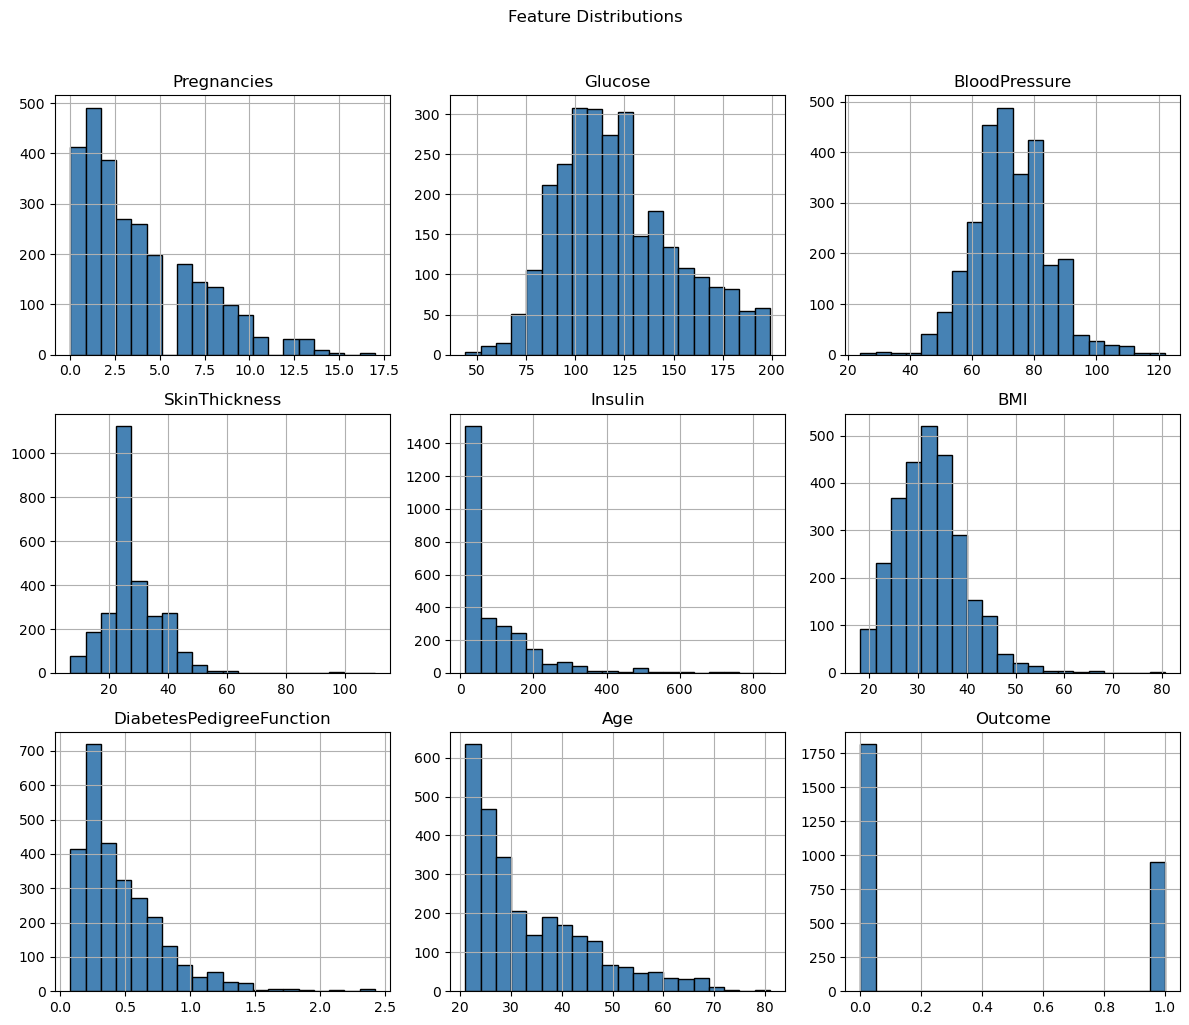

In [23]:
df.hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

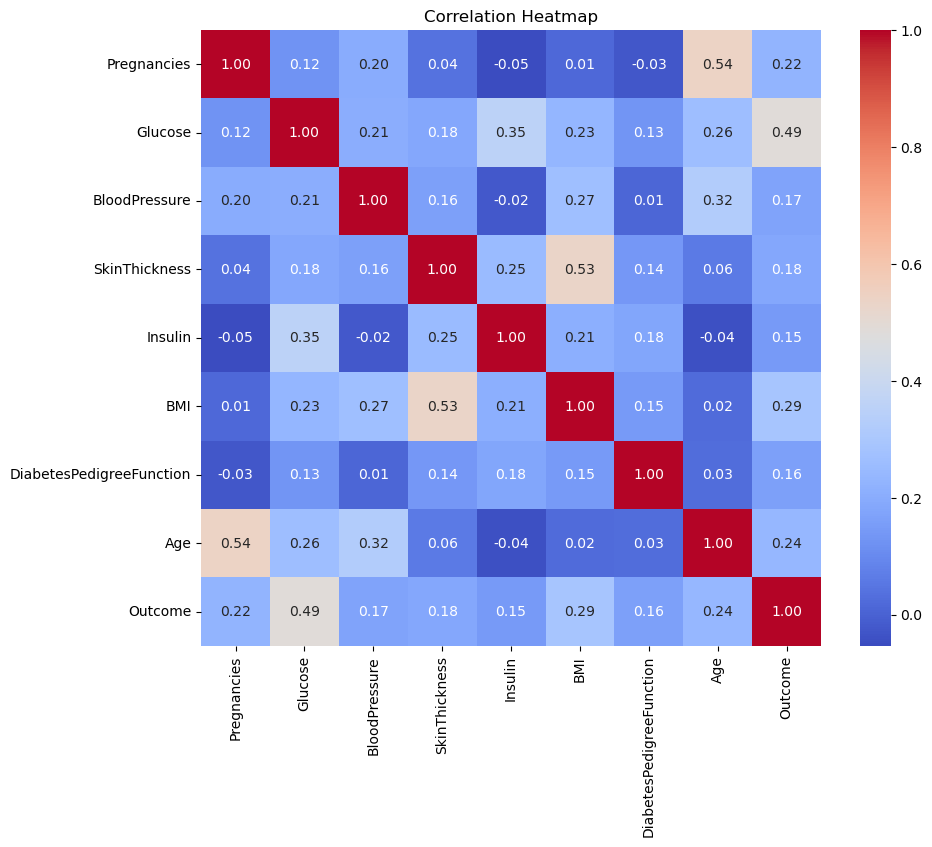

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [25]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [26]:
df[cols] = df[cols].fillna(df[cols].mean())

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

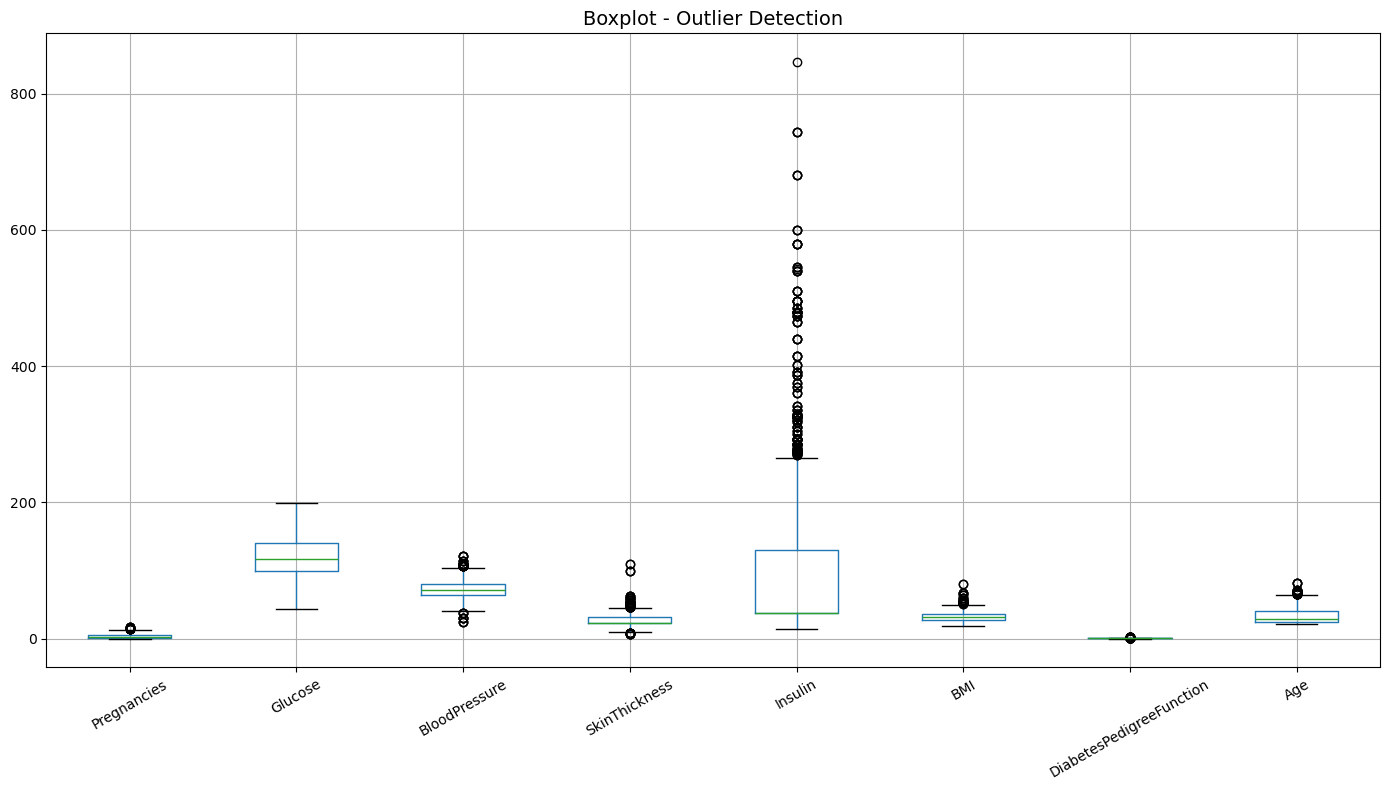

In [27]:
plt.figure(figsize=(14, 8))
df.drop('Outcome', axis=1).boxplot()
plt.title('Boxplot - Outlier Detection', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [28]:
def detect_outliers_iqr(data, feature):
    Q1  = data[feature].quantile(0.25)
    Q3  = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower) | (data[feature] > upper)]
    return outliers, lower, upper

features = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

print("=" * 55)
print(f"{'Feature':<28} {'Outliers':>8}  {'Lower':>8}  {'Upper':>8}")
print("=" * 55)

total_outliers = set()

for feature in features:
    outliers, lower, upper = detect_outliers_iqr(df, feature)
    total_outliers.update(outliers.index.tolist())
    print(f"{feature:<28} {len(outliers):>8}  {lower:>8.2f}  {upper:>8.2f}")

print("=" * 55)
print(f"Total rows with at least one outlier: {len(total_outliers)}")
print(f"Dataset shape before removal        : {df.shape}")

Feature                      Outliers     Lower     Upper
Pregnancies                        16     -6.50     13.50
Glucose                             0     36.00    204.00
BloodPressure                      49     40.00    104.00
SkinThickness                     131      9.50     45.50
Insulin                           185   -102.50    269.50
BMI                                38     14.00     50.20
DiabetesPedigreeFunction           97     -0.33      1.19
Age                                64      0.00     64.00
Total rows with at least one outlier: 516
Dataset shape before removal        : (2768, 9)


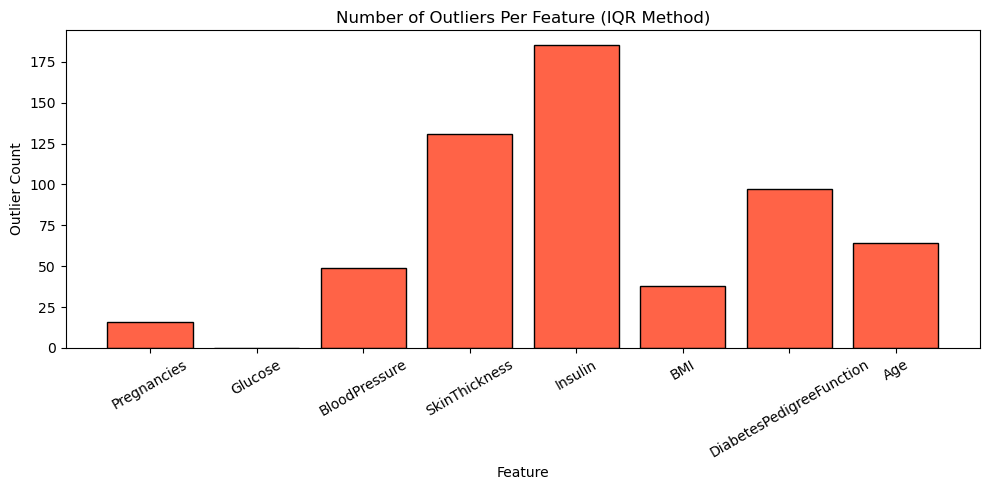

In [29]:
outlier_counts = {}

for feature in features:
    outliers, _, _ = detect_outliers_iqr(df, feature)
    outlier_counts[feature] = len(outliers)

plt.figure(figsize=(10, 5))
plt.bar(outlier_counts.keys(), outlier_counts.values(), color='tomato', edgecolor='black')
plt.title('Number of Outliers Per Feature (IQR Method)')
plt.xlabel('Feature')
plt.ylabel('Outlier Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [30]:
df_cleaned = df.copy()

for feature in features:
    Q1  = df_cleaned[feature].quantile(0.25)
    Q3  = df_cleaned[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[
        (df_cleaned[feature] >= lower) &
        (df_cleaned[feature] <= upper)
    ]

print(f"Shape BEFORE outlier removal : {df.shape}")
print(f"Shape AFTER  outlier removal : {df_cleaned.shape}")
print(f"Rows removed                 : {df.shape[0] - df_cleaned.shape[0]}")

Shape BEFORE outlier removal : (2768, 9)
Shape AFTER  outlier removal : (2197, 9)
Rows removed                 : 571


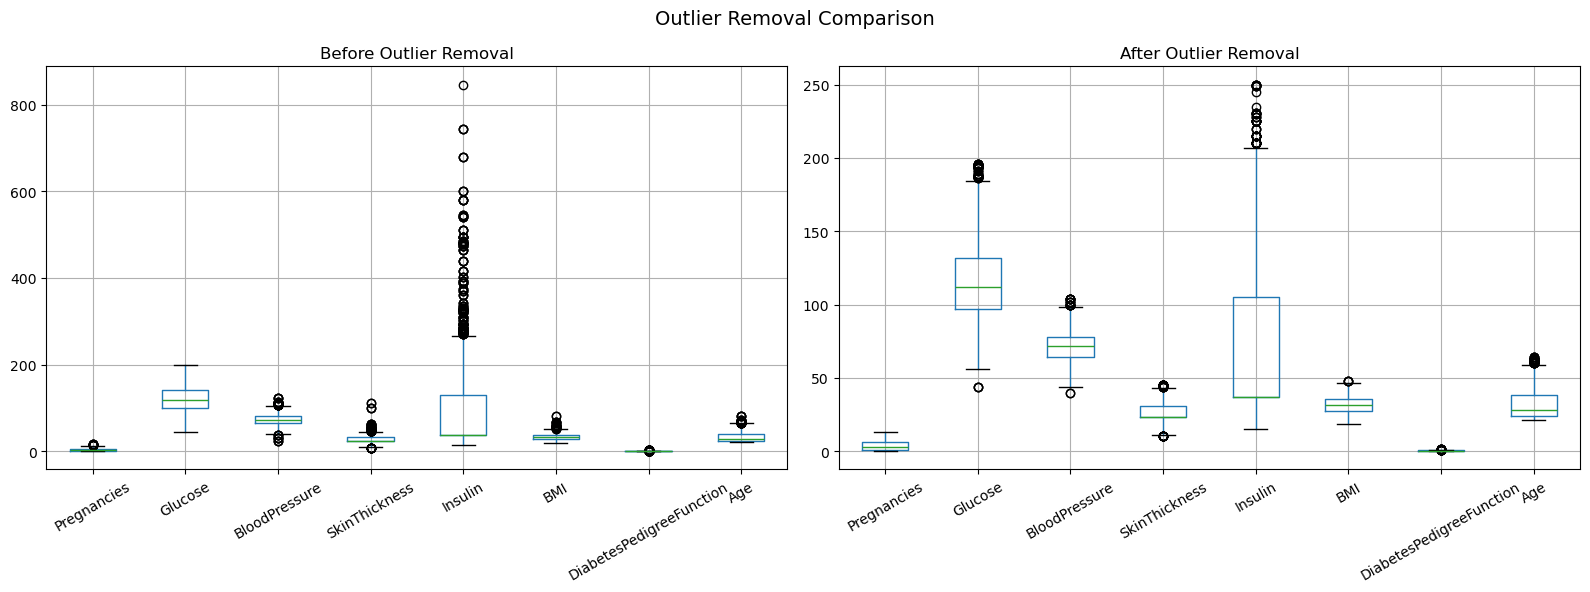

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.drop('Outcome', axis=1).boxplot(ax=axes[0])
axes[0].set_title('Before Outlier Removal')
axes[0].tick_params(axis='x', rotation=30)

df_cleaned.drop('Outcome', axis=1).boxplot(ax=axes[1])
axes[1].set_title('After Outlier Removal')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Outlier Removal Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# Use cleaned dataframe going forward
df = df_cleaned.reset_index(drop=True)

print("✅ Outliers removed!")
print(f"Final dataset shape: {df.shape}")
print("\nClass distribution after cleaning:")
print(df['Outcome'].value_counts())

✅ Outliers removed!
Final dataset shape: (2197, 9)

Class distribution after cleaning:
Outcome
0    1533
1     664
Name: count, dtype: int64


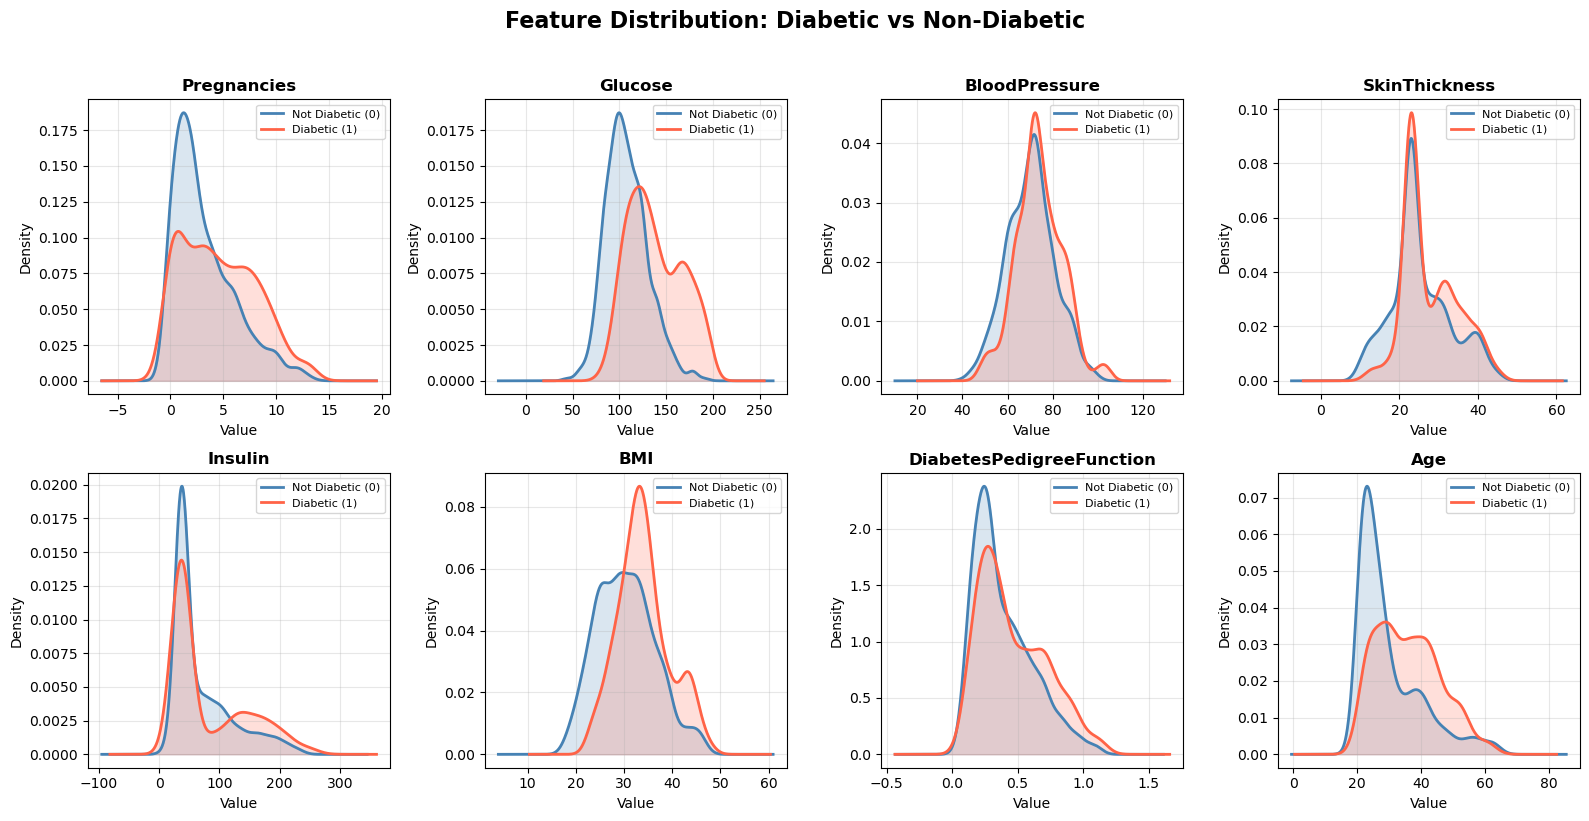

Graph saved as class_distribution_2d.png ✅


In [33]:
features = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, feature in zip(axes.flatten(), features):
    
    # Separate class 0 and class 1
    class0 = df[df['Outcome'] == 0][feature]
    class1 = df[df['Outcome'] == 1][feature]
    
    # Plot KDE for both classes
    class0.plot.kde(ax=ax, label='Not Diabetic (0)', 
                    color='steelblue', linewidth=2)
    class1.plot.kde(ax=ax, label='Diabetic (1)',    
                    color='tomato',    linewidth=2)
    
    # Fill under curve
    ax.fill_between(ax.lines[0].get_xdata(),
                    ax.lines[0].get_ydata(),
                    alpha=0.2, color='steelblue')
    ax.fill_between(ax.lines[1].get_xdata(),
                    ax.lines[1].get_ydata(),
                    alpha=0.2, color='tomato')
    
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distribution: Diabetic vs Non-Diabetic',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved as class_distribution_2d.png ✅")

In [34]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [35]:
from imblearn.over_sampling import SMOTE

Before SMOTE:
Outcome
0    1533
1     664
Name: count, dtype: int64


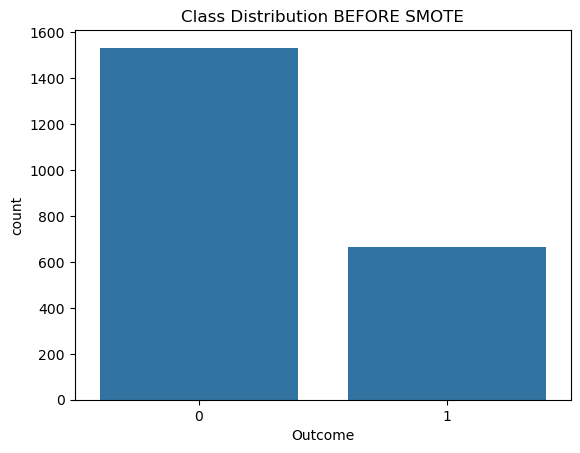

In [36]:
print("Before SMOTE:")
print(y.value_counts())


sns.countplot(x=y)
plt.title("Class Distribution BEFORE SMOTE")
plt.show()

In [37]:
# Step 1 - Replace zeros with NaN and fill with mean
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].mean())

# Step 2 - Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Step 3 - Apply SMOTE BEFORE train-test split
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:")
print(f"  Total Samples : {X_resampled.shape[0]}")
print(f"  Features      : {X_resampled.shape[1]}")
print(pd.Series(y_resampled).value_counts())

# Step 4 - Train test split on resampled data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("\nTraining size:", X_train.shape)
print("Testing size :", X_test.shape)

# Step 5 - Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nSMOTE + Scaling done ✅")

After SMOTE:
  Total Samples : 3066
  Features      : 8
Outcome
1    1533
0    1533
Name: count, dtype: int64

Training size: (2452, 8)
Testing size : (614, 8)

SMOTE + Scaling done ✅


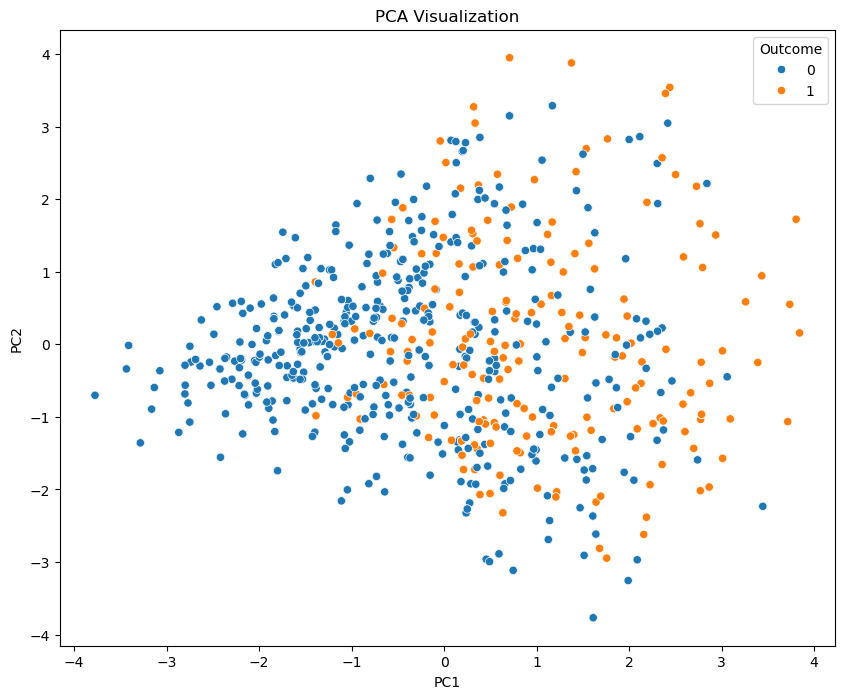

In [38]:


# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Outcome'] = y

# Plot
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Outcome',
    data=pca_df
)

plt.title("PCA Visualization")
plt.show()

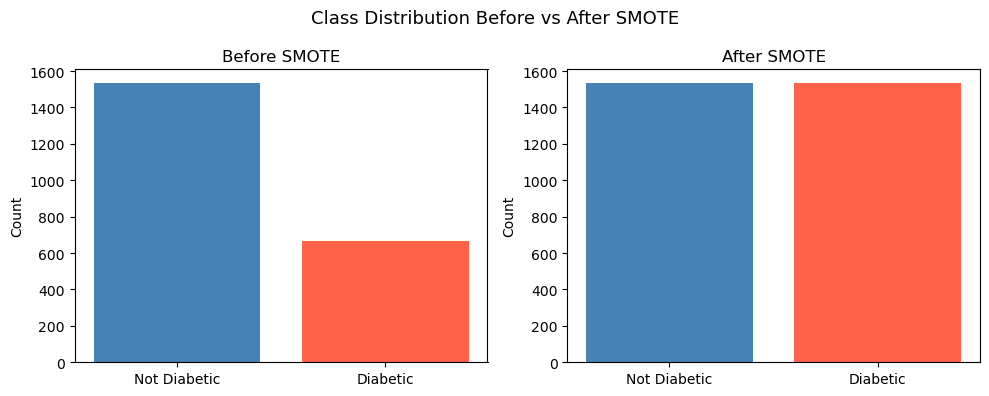

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
axes[0].bar(['Not Diabetic', 'Diabetic'],
            df['Outcome'].value_counts().sort_index(),
            color=['steelblue', 'tomato'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

# After
axes[1].bar(['Not Diabetic', 'Diabetic'],
            pd.Series(y_resampled).value_counts().sort_index(),
            color=['steelblue', 'tomato'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

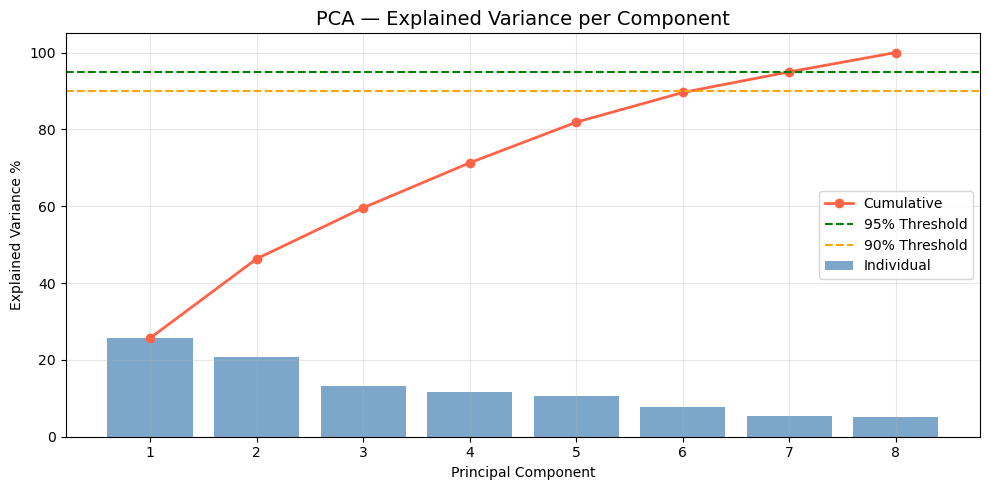


Cumulative Explained Variance:
  1 components → 25.66%
  2 components → 46.30%
  3 components → 59.59%
  4 components → 71.30%
  5 components → 81.86%
  6 components → 89.60%
  7 components → 94.97%
  8 components → 100.00%


In [40]:
pca_check = PCA()
pca_check.fit(X_train)

explained_variance = pca_check.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))

# Bar - individual variance
plt.bar(range(1, len(explained_variance)+1), 
        explained_variance * 100,
        color='steelblue', alpha=0.7, label='Individual')

# Line - cumulative variance
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance * 100,
         color='tomato', marker='o', linewidth=2, label='Cumulative')

plt.axhline(y=95, color='green', linestyle='--', label='95% Threshold')
plt.axhline(y=90, color='orange', linestyle='--', label='90% Threshold')

plt.title('PCA — Explained Variance per Component', fontsize=14)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance %')
plt.xticks(range(1, len(explained_variance)+1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCumulative Explained Variance:")
for i, val in enumerate(cumulative_variance):
    print(f"  {i+1} components → {val*100:.2f}%")

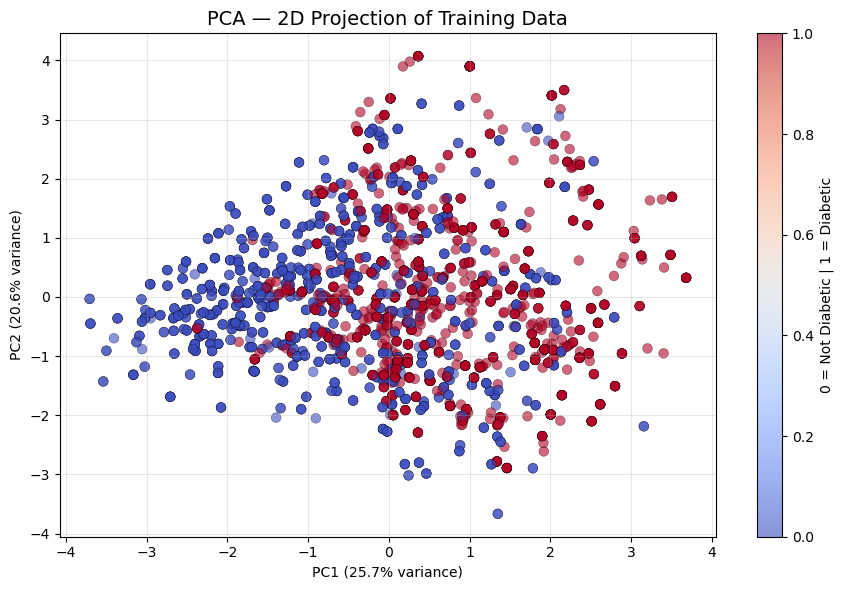

PC1 explains: 25.66%
PC2 explains: 20.65%
Total explained: 46.30%


In [41]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=y_train,
                      cmap='coolwarm',
                      alpha=0.6,
                      edgecolors='k',
                      linewidths=0.3,
                      s=50)

plt.colorbar(scatter, label='0 = Not Diabetic | 1 = Diabetic')
plt.title('PCA — 2D Projection of Training Data', fontsize=14)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total explained: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

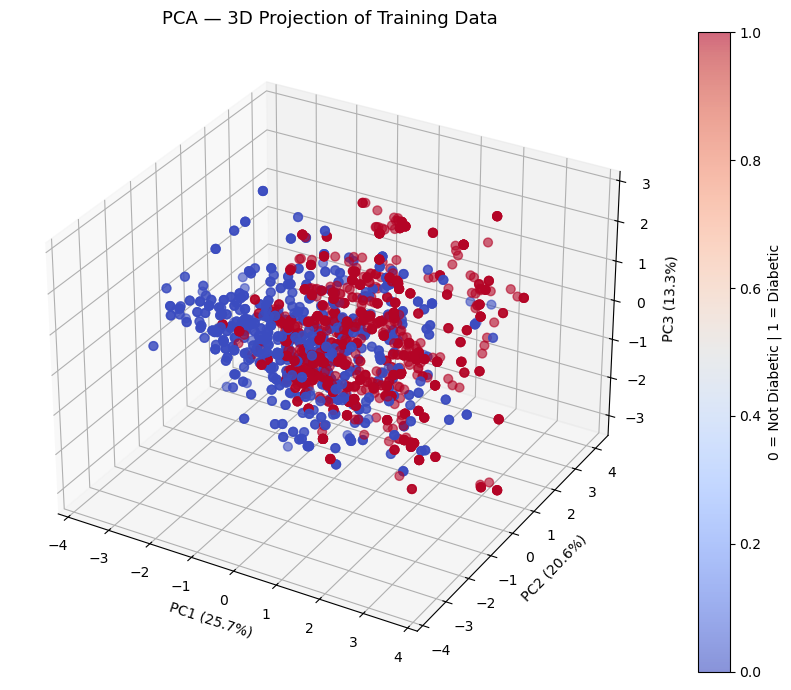

In [42]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_train)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0],
                     X_pca_3d[:, 1],
                     X_pca_3d[:, 2],
                     c=y_train,
                     cmap='coolwarm',
                     alpha=0.6,
                     s=40)

fig.colorbar(scatter, label='0 = Not Diabetic | 1 = Diabetic')
ax.set_title('PCA — 3D Projection of Training Data', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
plt.tight_layout()
plt.savefig('pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Keep 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"Original features  : {X_train.shape[1]}")
print(f"After PCA features : {X_train_pca.shape[1]}")
print(f"Variance retained  : {sum(pca.explained_variance_ratio_)*100:.2f}%")

Original features  : 8
After PCA features : 8
Variance retained  : 100.00%


                     Without PCA  With PCA
Model                                     
Logistic Regression        71.82     71.82
Random Forest              98.37     98.37
SVM                        84.53     84.53
Gradient Boosting          88.76     88.76


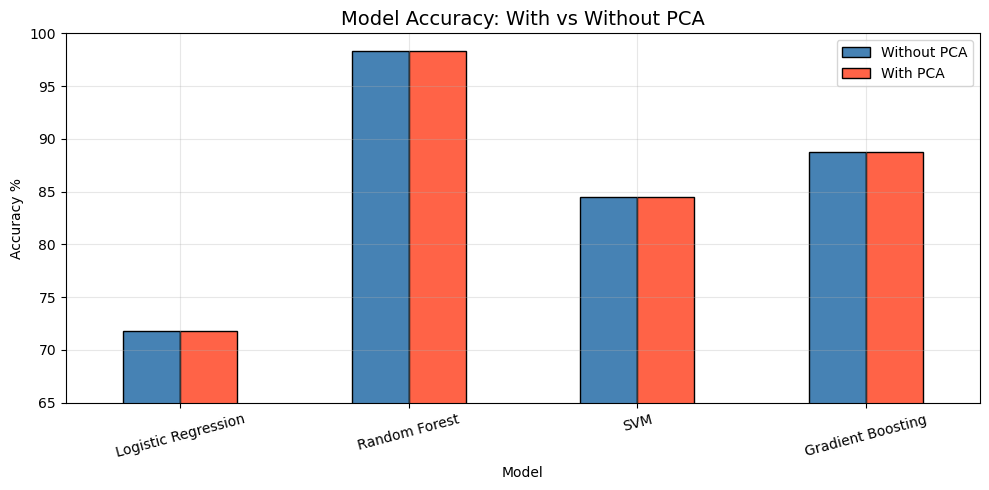

In [44]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models_compare = {
    'Logistic Regression' : LogisticRegression(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {'Model': [], 'Without PCA': [], 'With PCA': []}

for name, model in models_compare.items():
    # Without PCA
    model.fit(X_train, y_train)
    acc_without = accuracy_score(y_test, model.predict(X_test))

    # With PCA
    model.fit(X_train_pca, y_train)
    acc_with = accuracy_score(y_test, model.predict(X_test_pca))

    results['Model'].append(name)
    results['Without PCA'].append(round(acc_without * 100, 2))
    results['With PCA'].append(round(acc_with * 100, 2))

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

# Visualize
results_df.plot(kind='bar', figsize=(10, 5),
                color=['steelblue', 'tomato'],
                edgecolor='black')
plt.title('Model Accuracy: With vs Without PCA', fontsize=14)
plt.ylabel('Accuracy %')
plt.ylim(65, 100)
plt.xticks(rotation=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7182410423452769


In [46]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9837133550488599


In [47]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8452768729641694


In [48]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.8876221498371335


In [49]:
models = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'SVM': accuracy_score(y_test, svm_pred),
    'Gradient Boosting': accuracy_score(y_test, gb_pred)
}

for model, acc in models.items():
    print(f"{model}: {acc*100:.2f}%")

Logistic Regression: 71.82%
Random Forest: 98.37%
SVM: 84.53%
Gradient Boosting: 88.76%


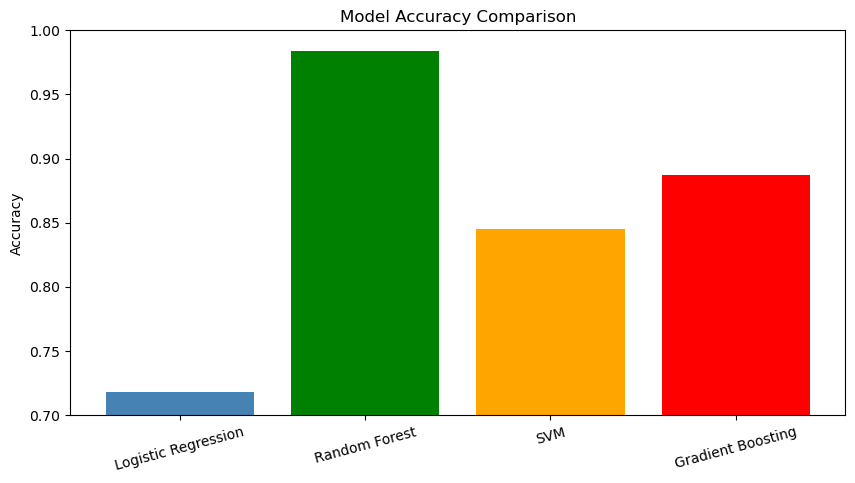

In [50]:
plt.figure(figsize=(10, 5))
plt.bar(models.keys(), models.values(), color=['steelblue','green','orange','red'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)
plt.show()

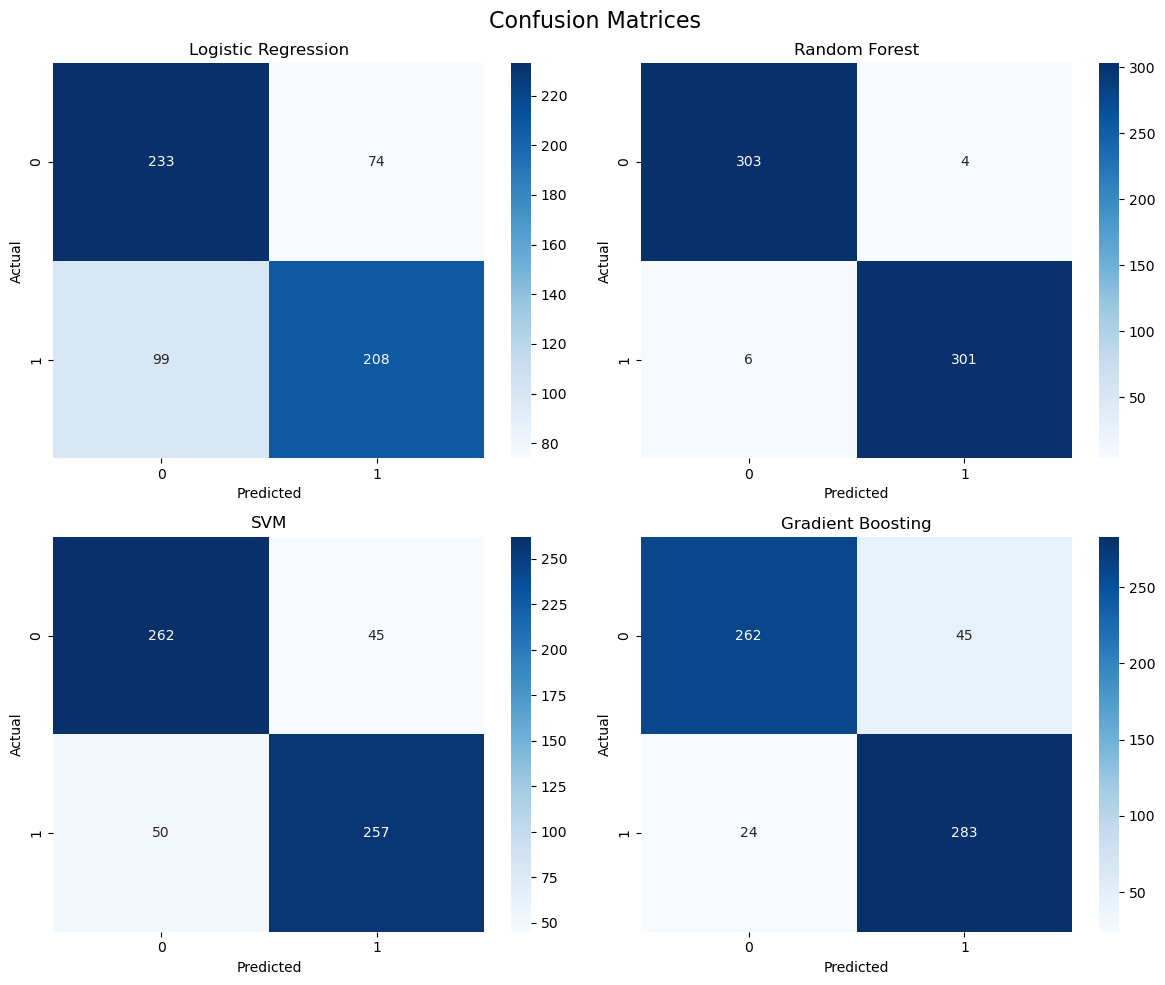

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_preds = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'SVM': svm_pred,
    'Gradient Boosting': gb_pred
}

for ax, (model_name, pred) in zip(axes.flatten(), models_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

In [52]:
print("=== Gradient Boosting Classification Report ===\n")
print(classification_report(y_test, gb_pred, target_names=['No Diabetes', 'Diabetes']))

=== Gradient Boosting Classification Report ===

              precision    recall  f1-score   support

 No Diabetes       0.92      0.85      0.88       307
    Diabetes       0.86      0.92      0.89       307

    accuracy                           0.89       614
   macro avg       0.89      0.89      0.89       614
weighted avg       0.89      0.89      0.89       614



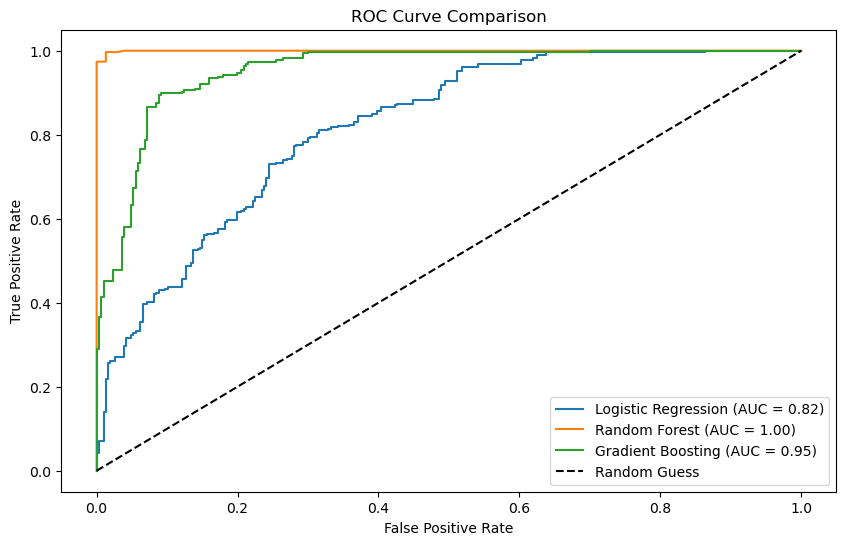

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 6))

models_list = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

for model_name, model in models_list.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

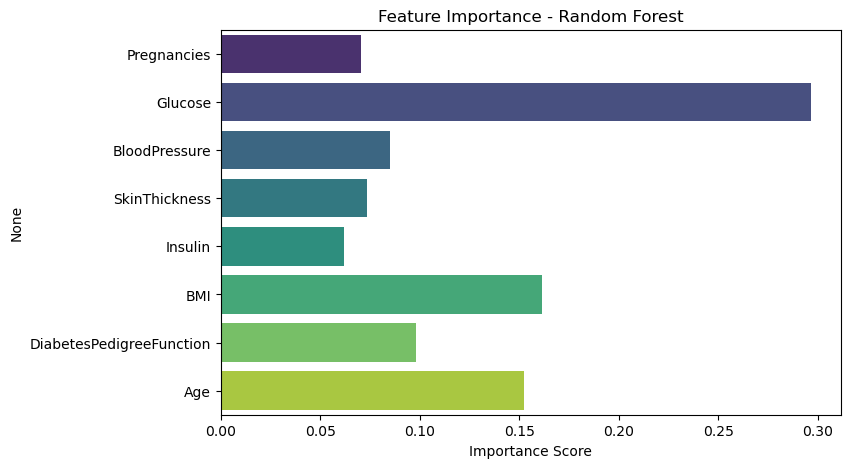

In [54]:
feature_names = df.drop('Outcome', axis=1).columns
importances = rf.feature_importances_

plt.figure(figsize=(8, 5))

sns.barplot(
    x=importances,
    y=feature_names,
    hue=feature_names,
    palette='viridis',
    legend=False
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, gb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, gb_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, gb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, gb_pred)
    ]
})

summary.set_index('Model')

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.718241,0.737589,0.677524,0.706282
Random Forest,0.983713,0.986885,0.980456,0.983660
SVM,0.845277,0.850993,0.837134,0.844007
Gradient Boosting,0.887622,0.862805,0.921824,0.891339


In [56]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [57]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Accuracy:", rf_grid.best_score_*100, "%")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 98.32777754686394 %


In [58]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV Accuracy:", gb_grid.best_score_*100, "%")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV Accuracy: 98.28712747828256 %


In [59]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV Accuracy:", lr_grid.best_score_*100, "%")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}
Best CV Accuracy: 76.34648156614988 %


In [60]:
# Predictions with best models
rf_best_pred = rf_grid.best_estimator_.predict(X_test)
gb_best_pred = gb_grid.best_estimator_.predict(X_test)
lr_best_pred = lr_grid.best_estimator_.predict(X_test)

print("Tuned Random Forest Accuracy:      ", accuracy_score(y_test, rf_best_pred)*100, "%")
print("Tuned Gradient Boosting Accuracy:  ", accuracy_score(y_test, gb_best_pred)*100, "%")
print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, lr_best_pred)*100, "%")

Tuned Random Forest Accuracy:       98.69706840390879 %
Tuned Gradient Boosting Accuracy:   98.53420195439739 %
Tuned Logistic Regression Accuracy: 71.82410423452768 %


CV Scores: [0.99186992 1.         0.98373984 0.98373984 1.         0.99186992
 0.99186992 0.99186992 1.         1.         0.98373984 0.97560976
 0.97540984 0.99180328 0.98360656 1.         0.99180328 0.98360656
 0.98360656 1.        ]
Mean Accuracy: 99.02%
Std Deviation: 0.80%


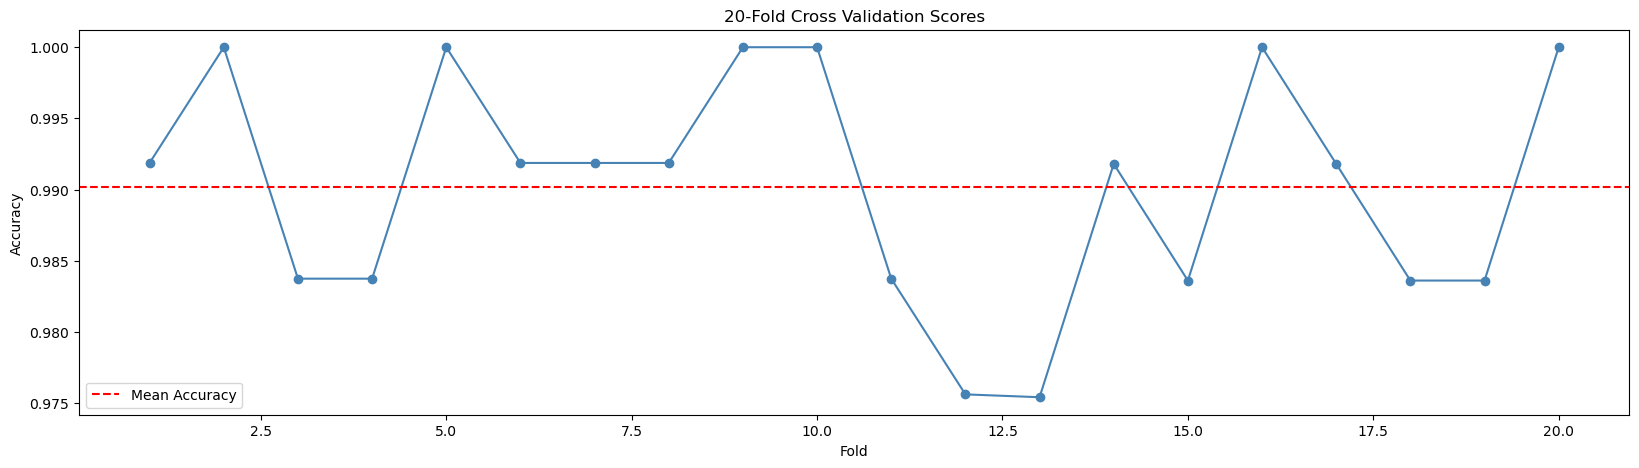

In [61]:
best_model = rf_grid.best_estimator_  # change if GB is better

cv_scores = cross_val_score(best_model, X_train, y_train, cv=20, scoring='accuracy')

print("CV Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation: {cv_scores.std()*100:.2f}%")

plt.figure(figsize=(20, 5))
plt.plot(range(1, 21), cv_scores, marker='o', color='steelblue')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label='Mean Accuracy')
plt.title('20-Fold Cross Validation Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

                 Model  Before Tuning  After Tuning
0        Random Forest      98.371336     98.697068
1    Gradient Boosting      88.762215     98.534202
2  Logistic Regression      71.824104     71.824104


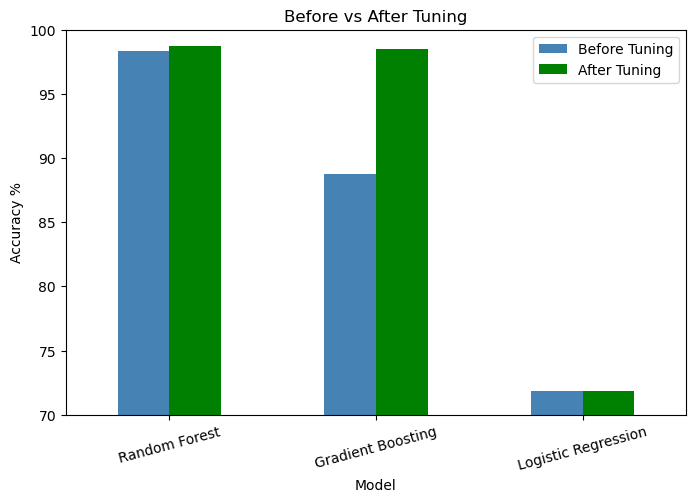

In [62]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Logistic Regression'],
    'Before Tuning': [
        accuracy_score(y_test, rf_pred)*100,
        accuracy_score(y_test, gb_pred)*100,
        accuracy_score(y_test, lr_pred)*100
    ],
    'After Tuning': [
        accuracy_score(y_test, rf_best_pred)*100,
        accuracy_score(y_test, gb_best_pred)*100,
        accuracy_score(y_test, lr_best_pred)*100
    ]
})

print(comparison)

# Visualize
comparison.set_index('Model').plot(kind='bar', figsize=(8, 5), color=['steelblue', 'green'])
plt.title('Before vs After Tuning')
plt.ylabel('Accuracy %')
plt.xticks(rotation=15)
plt.ylim(70, 100)
plt.legend()
plt.show()

In [63]:
import pickle

# Save the best model
best_model = rf_grid.best_estimator_  # or gb_grid.best_estimator_

with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler too (very important!)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and Scaler saved successfully! ✅")

Model and Scaler saved successfully! ✅


In [64]:
# Load model back
with open('diabetes_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Load scaler back
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("Model and Scaler loaded successfully! ✅")

Model and Scaler loaded successfully! ✅


In [65]:
# Sample new patient data as DataFrame (with column names)
new_patient = pd.DataFrame([[6, 148, 72, 35, 0, 33.6, 0.627, 50]], 
                            columns=['Pregnancies', 'Glucose', 'BloodPressure', 
                                     'SkinThickness', 'Insulin', 'BMI', 
                                     'DiabetesPedigreeFunction', 'Age'])

# Scale the input
new_patient_scaled = loaded_scaler.transform(new_patient)

# Predict
prediction = loaded_model.predict(new_patient_scaled)
probability = loaded_model.predict_proba(new_patient_scaled)

print("Input Data:")
print(f"  Pregnancies: 6, Glucose: 148, BloodPressure: 72")
print(f"  SkinThickness: 35, Insulin: 0, BMI: 33.6")
print(f"  DiabetesPedigreeFunction: 0.627, Age: 50")
print()
print(f"Prediction: {'Diabetic 🔴' if prediction[0] == 1 else 'Not Diabetic 🟢'}")
print(f"Probability of Diabetes: {probability[0][1]*100:.2f}%")
print(f"Probability of No Diabetes: {probability[0][0]*100:.2f}%")

Input Data:
  Pregnancies: 6, Glucose: 148, BloodPressure: 72
  SkinThickness: 35, Insulin: 0, BMI: 33.6
  DiabetesPedigreeFunction: 0.627, Age: 50

Prediction: Diabetic 🔴
Probability of Diabetes: 74.50%
Probability of No Diabetes: 25.50%


In [66]:
def predict_diabetes(pregnancies, glucose, blood_pressure, 
                     skin_thickness, insulin, bmi, 
                     diabetes_pedigree, age):
    
    # Prepare input as DataFrame with column names
    input_data = pd.DataFrame([[pregnancies, glucose, blood_pressure,
                                skin_thickness, insulin, bmi,
                                diabetes_pedigree, age]],
                              columns=['Pregnancies', 'Glucose', 'BloodPressure',
                                       'SkinThickness', 'Insulin', 'BMI',
                                       'DiabetesPedigreeFunction', 'Age'])
    
    # Scale input
    input_scaled = loaded_scaler.transform(input_data)
    
    # Predict
    prediction = loaded_model.predict(input_scaled)
    probability = loaded_model.predict_proba(input_scaled)
    
    print("=" * 40)
    print("       DIABETES PREDICTION RESULT")
    print("=" * 40)
    print(f"Result     : {'Diabetic 🔴' if prediction[0] == 1 else 'Not Diabetic 🟢'}")
    print(f"Diabetes % : {probability[0][1]*100:.2f}%")
    print(f"Healthy %  : {probability[0][0]*100:.2f}%")
    print("=" * 40)
    
    return prediction[0]

In [67]:
# Test with different patients

# Patient 1 - High Risk
predict_diabetes(
    pregnancies=8,
    glucose=183,
    blood_pressure=64,
    skin_thickness=0,
    insulin=0,
    bmi=23.3,
    diabetes_pedigree=0.672,
    age=32
)

       DIABETES PREDICTION RESULT
Result     : Diabetic 🔴
Diabetes % : 54.50%
Healthy %  : 45.50%


np.int64(1)

In [68]:
# Patient 2 - Low Risk
predict_diabetes(
    pregnancies=1,
    glucose=89,
    blood_pressure=66,
    skin_thickness=23,
    insulin=94,
    bmi=28.1,
    diabetes_pedigree=0.167,
    age=21
)

       DIABETES PREDICTION RESULT
Result     : Not Diabetic 🟢
Diabetes % : 2.50%
Healthy %  : 97.50%


np.int64(0)

In [69]:
# Multiple patients at once
new_patients = pd.DataFrame({
    'Pregnancies':             [6, 1, 8, 2],
    'Glucose':                 [148, 89, 183, 120],
    'BloodPressure':           [72, 66, 64, 70],
    'SkinThickness':           [35, 23, 0, 30],
    'Insulin':                 [0, 94, 0, 80],
    'BMI':                     [33.6, 28.1, 23.3, 32.0],
    'DiabetesPedigreeFunction':[0.627, 0.167, 0.672, 0.450],
    'Age':                     [50, 21, 32, 45]
})

# Scale and predict
new_patients_scaled = loaded_scaler.transform(new_patients)
predictions = loaded_model.predict(new_patients_scaled)
probabilities = loaded_model.predict_proba(new_patients_scaled)

new_patients['Prediction'] = ['Diabetic 🔴' if p == 1 else 'Not Diabetic 🟢' for p in predictions]
new_patients['Diabetes Probability %'] = (probabilities[:, 1] * 100).round(2)

new_patients[['Prediction', 'Diabetes Probability %']]

,Prediction,Diabetes Probability %
0,Diabetic 🔴,74.5
1,Not Diabetic 🟢,2.5
2,Diabetic 🔴,54.5
3,Diabetic 🔴,65.5


In [70]:
print("=" * 55)
print("       DIABETES PREDICTION - PROJECT SUMMARY")
print("=" * 55)
print(f"  Dataset        : Pima Indians Diabetes Dataset")
print(f"  Total Samples  : {df.shape[0]}")
print(f"  Total Features : {df.shape[1] - 1}")
print(f"  Target Classes : Diabetic (1) / Not Diabetic (0)")
print("=" * 55)

       DIABETES PREDICTION - PROJECT SUMMARY
  Dataset        : Pima Indians Diabetes Dataset
  Total Samples  : 2197
  Total Features : 8
  Target Classes : Diabetic (1) / Not Diabetic (0)


In [71]:
final_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'Gradient Boosting'],
    'Before Tuning %': [
        round(accuracy_score(y_test, lr_pred)*100, 2),
        round(accuracy_score(y_test, rf_pred)*100, 2),
        round(accuracy_score(y_test, svm_pred)*100, 2),
        round(accuracy_score(y_test, gb_pred)*100, 2)
    ],
    'After Tuning %': [
        round(accuracy_score(y_test, lr_best_pred)*100, 2),
        round(accuracy_score(y_test, rf_best_pred)*100, 2),
        round(accuracy_score(y_test, svm_pred)*100, 2),
        round(accuracy_score(y_test, gb_best_pred)*100, 2)
    ]
})

final_summary.set_index('Model')

,Before Tuning %,After Tuning %
Model,,
Logistic Regression,71.82,71.82
Random Forest,98.37,98.70
SVM,84.53,84.53
Gradient Boosting,88.76,98.53


In [72]:
best_acc = max(
    accuracy_score(y_test, lr_best_pred),
    accuracy_score(y_test, rf_best_pred),
    accuracy_score(y_test, gb_best_pred)
)

best_name = ['Logistic Regression', 'Random Forest', 'Gradient Boosting'][
    [accuracy_score(y_test, lr_best_pred),
     accuracy_score(y_test, rf_best_pred),
     accuracy_score(y_test, gb_best_pred)].index(best_acc)
]

print("=" * 45)
print(f"  🏆 Best Model   : {best_name}")
print(f"  ✅ Best Accuracy : {best_acc*100:.2f}%")
print("=" * 45)

  🏆 Best Model   : Random Forest
  ✅ Best Accuracy : 98.70%


In [73]:
steps = [
    "1. Import Libraries",
    "2. Load Dataset",
    "3. EDA & Visualization",
    "4. Data Preprocessing",
    "5. Train ML Models",
    "6. Model Evaluation",
    "7. Hyperparameter Tuning",
    "8. Save & Predict",
    "9. Final Report"
]

print("=" * 40)
print("      PROJECT PIPELINE STEPS")
print("=" * 40)
for step in steps:
    print(f"  ✅ {step}")
print("=" * 40)
print("  🎉 Project Completed Successfully!")
print("=" * 40)

      PROJECT PIPELINE STEPS
  ✅ 1. Import Libraries
  ✅ 2. Load Dataset
  ✅ 3. EDA & Visualization
  ✅ 4. Data Preprocessing
  ✅ 5. Train ML Models
  ✅ 6. Model Evaluation
  ✅ 7. Hyperparameter Tuning
  ✅ 8. Save & Predict
  ✅ 9. Final Report
  🎉 Project Completed Successfully!


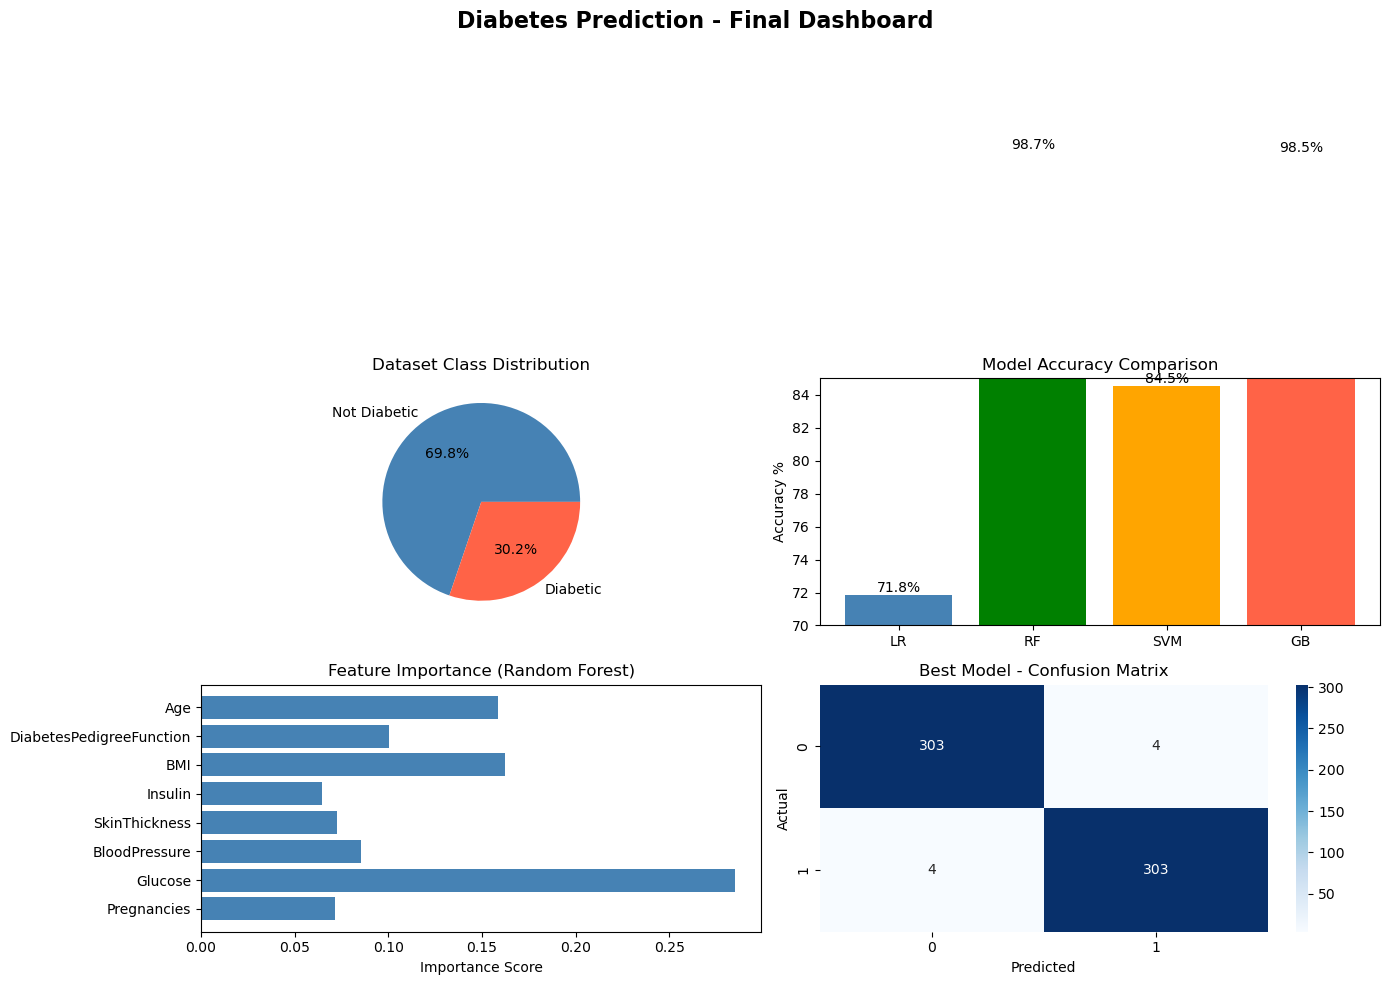

Dashboard saved as diabetes_dashboard.png ✅


In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diabetes Prediction - Final Dashboard', fontsize=16, fontweight='bold')

# Plot 1 - Class Distribution
axes[0, 0].pie(df['Outcome'].value_counts(), 
               labels=['Not Diabetic', 'Diabetic'],
               autopct='%1.1f%%', 
               colors=['steelblue', 'tomato'])
axes[0, 0].set_title('Dataset Class Distribution')

# Plot 2 - Model Accuracy Comparison
model_names = ['LR', 'RF', 'SVM', 'GB']
accuracies = [
    accuracy_score(y_test, lr_best_pred)*100,
    accuracy_score(y_test, rf_best_pred)*100,
    accuracy_score(y_test, svm_pred)*100,
    accuracy_score(y_test, gb_best_pred)*100
]
bars = axes[0, 1].bar(model_names, accuracies, color=['steelblue','green','orange','tomato'])
axes[0, 1].set_title('Model Accuracy Comparison')
axes[0, 1].set_ylabel('Accuracy %')
axes[0, 1].set_ylim(70, 85)
for bar, acc in zip(bars, accuracies):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + 0.2, 
                    f'{acc:.1f}%', ha='center', fontsize=10)

# Plot 3 - Feature Importance
feature_names = df.drop('Outcome', axis=1).columns
importances = rf_grid.best_estimator_.feature_importances_
axes[1, 0].barh(feature_names, importances, color='steelblue')
axes[1, 0].set_title('Feature Importance (Random Forest)')
axes[1, 0].set_xlabel('Importance Score')

# Plot 4 - Confusion Matrix of Best Model
cm = confusion_matrix(y_test, rf_best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Best Model - Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('diabetes_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard saved as diabetes_dashboard.png ✅")

In [75]:
import os

files = ['diabetes_model.pkl', 'scaler.pkl', 'diabetes_dashboard.png']

print("=" * 40)
print("      FILES GENERATED IN PROJECT")
print("=" * 40)
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"  ✅ {f} ({size} bytes)")
    else:
        print(f"  ❌ {f} not found")
print("=" * 40)

      FILES GENERATED IN PROJECT
  ✅ diabetes_model.pkl (5746416 bytes)
  ✅ scaler.pkl (834 bytes)
  ✅ diabetes_dashboard.png (132731 bytes)


In [81]:
print("""
==============================================
           PROJECT CONCLUSION
==============================================

 ✅ Successfully built a Diabetes Prediction
    system using Machine Learning.

 📊 Models Trained:
    - Logistic Regression
    - Random Forest
    - Support Vector Machine
    - Gradient Boosting

 🔧 Techniques Used:
    - Exploratory Data Analysis
    - Missing Value Treatment
    - Feature Scaling
    - Hyperparameter Tuning (GridSearchCV)
    - Cross Validation
    - ROC-AUC Evaluation

 💾 Deliverables:
    - Trained Model (diabetes_model.pkl)
    - Scaler (scaler.pkl)
    - Dashboard (diabetes_dashboard.png)

 🏆 Glucose & BMI are the most important
    features for predicting diabetes.

==============================================
""")


           PROJECT CONCLUSION

 ✅ Successfully built a Diabetes Prediction
    system using Machine Learning.

 📊 Models Trained:
    - Logistic Regression
    - Random Forest
    - Support Vector Machine
    - Gradient Boosting

 🔧 Techniques Used:
    - Exploratory Data Analysis
    - Missing Value Treatment
    - Feature Scaling
    - Hyperparameter Tuning (GridSearchCV)
    - Cross Validation
    - ROC-AUC Evaluation

 💾 Deliverables:
    - Trained Model (diabetes_model.pkl)
    - Scaler (scaler.pkl)
    - Dashboard (diabetes_dashboard.png)

 🏆 Glucose & BMI are the most important
    features for predicting diabetes.


